# Projet 2 —  Prédiction du risque d’accident de vélo

**Membres du groupe :**
- ABEGUEDIE Rosane Yvanne Boyama  
- BARRY Mamoudou  
- DAMIENS Elodie  
- GUILLEMINOT Paul  
- TOUAMI Zakaria

**Groupe :** D  
**Jeu de données :** `accidentsVelo.csv`  
- **Objectif :** comprendre les facteurs qui influencent la gravité d'un accident impliquant un cycliste
- **Prédire** la probabilité qu'un accident soit grave (tué ou blessé hospitalisé)
- **Identifier** des leviers de prévention

## 1. Problématique et logique d'analyse

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

# XGBoost est utilisé seulement s'il est disponible
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

# Style graphique
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Chargement des données

Source : [data.gouv.fr — Accidents de vélo](https://www.data.gouv.fr/datasets/accidents-de-velo) (version janvier 2026).

On commence par charger le fichier CSV puis par vérifier sa structure générale.  

Ce jeu de données est extrait du **fichier BAAC** (Bulletin d'Analyse des Accidents Corporels) administré par l'ONISR. Il recense les accidents corporels de la circulation, survenus en France entre 2005 et 2023, dans lesquels au moins une personne à vélo a été impliquée.

### But et utilité de l'étape

**But :** charger les données dans un format exploitable et vérifier rapidement leur structure (taille, types, valeurs manquantes).

**Utilité :** valider qu'on travaille sur le bon périmètre avant toute interprétation ou modélisation.


In [18]:
df = pd.read_csv("accidentsVelo.csv", sep=",")
print(f"Dimensions du dataset : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
display(df.head())

Dimensions du dataset : 80,022 lignes × 39 colonnes


C:\Users\Paul\AppData\Local\Temp\ipykernel_17092\1477198848.py:1: DtypeWarning: Columns (0: lat, 1: long, 2: nbv, 3: lartpc, 4: larrout, 5: equipement) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accidentsVelo.csv", sep=",")


,Num_Acc,date,an,mois,jour,hrmn,dep,com,lat,long,agg,int,col,lum,atm,catr,circ,nbv,prof,plan,lartpc,larrout,surf,infra,situ,grav,sexe,age,trajet,secuexist,equipement,obs,obsm,choc,manv,vehiculeid,typevehicules,manoeuvehicules,numVehicules
0,200500000030,2005-01-13,2005,janvier,jeudi,19:45,62,62331,50.300,2.840,2,1,3.000,5,1.000,3,2.000,0,-1.000,1.000,0,50,1.000,0.000,1.000,4,1,58.000,5.000,3,0,0.000,2.000,8.000,11.000,200500000030B02,18,17,1.000
1,200500000034,2005-01-19,2005,janvier,mercredi,10:45,62,62022,0.000,0.000,1,1,1.000,1,7.000,3,2.000,0,1.000,3.000,0,50,1.000,0.000,1.000,3,1,20.000,5.000,3,0,0.000,2.000,1.000,1.000,200500000034B02,10,15,1.000
2,200500000078,2005-01-26,2005,janvier,mercredi,13:15,02,02173,0.000,0.000,1,9,3.000,1,1.000,3,2.000,2,2.000,1.000,0,0,1.000,0.000,1.000,4,1,71.000,5.000,2,2,0.000,2.000,1.000,1.000,200500000078B02,7,15,1.000
3,200500000093,2005-01-03,2005,janvier,lundi,13:30,02,02810,49.255,3.094,2,1,1.000,1,1.000,3,2.000,0,1.000,2.000,0,52,1.000,0.000,1.000,3,2,51.000,4.000,3,0,0.000,2.000,3.000,21.000,200500000093B02,7,21,1.000
4,200500000170,2005-01-29,2005,janvier,samedi,18:30,76,76196,0.000,0.000,1,1,2.000,3,1.000,3,2.000,2,1.000,1.000,0,50,1.000,0.000,1.000,4,1,74.000,5.000,1,9,0.000,2.000,4.000,2.000,200500000170A01,10,2,1.000


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 80022 entries, 0 to 80021
Data columns (total 39 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Num_Acc          80022 non-null  int64  
 1   date             80022 non-null  str    
 2   an               80022 non-null  int64  
 3   mois             80022 non-null  str    
 4   jour             80022 non-null  str    
 5   hrmn             80022 non-null  str    
 6   dep              80022 non-null  str    
 7   com              80022 non-null  str    
 8   lat              80022 non-null  object 
 9   long             79754 non-null  object 
 10  agg              80022 non-null  int64  
 11  int              80022 non-null  int64  
 12  col              80018 non-null  float64
 13  lum              80022 non-null  int64  
 14  atm              80019 non-null  float64
 15  catr             80022 non-null  int64  
 16  circ             79879 non-null  float64
 17  nbv              79825 

## Lecture initiale

Le dataset contient des variables : 

A DEFINIR SI ON FAIT CA

## 3. Data canvas - compréhension des variables

A DEFINIR SI ON FAIT CA

Avant de modéliser, il faut expliciter le rôle des variables.
Cette étape aide à distinguer :

- les variables probablement prédictives ;
- les variables possiblement redondantes ;
- les variables qui peuvent créer un biais de fuite d'information.

### But et utilité de l'étape
**But :** décrire les variables métier et leur rôle potentiel dans la prédiction.

**Utilité :** éviter les erreurs de lecture (variables redondantes, ambiguïté métier, risque de fuite d'information).

In [20]:
description = pd.DataFrame({
    "variable": df.columns,
    "type": df.dtypes.astype(str).values,
    "nb_modalites_ou_infos": [df[col].nunique() for col in df.columns],
    "exemple": [df[col].dropna().iloc[0] if df[col].notna().any() else np.nan for col in df.columns]
})

display(description)

,variable,type,nb_modalites_ou_infos,exemple
0,Num_Acc,int64,76186,200500000030
1,date,str,6891,2005-01-13
2,an,int64,19,2005
3,mois,str,12,janvier
4,jour,str,7,jeudi
5,hrmn,str,1244,19:45
6,dep,str,113,62
7,com,str,11637,62331
8,lat,object,31834,50.300
9,long,object,33366,2.840


### Hypothèses métier formulées avant l'EDA

A DEFINIR SI ON FAIT CA

## 4. Décodage des variables (codification BAAC)

Les variables sont codées numériquement selon la nomenclature officielle BAAC. Pour rendre les analyses lisibles, nous créons un dictionnaire de correspondance pour chaque variable catégorielle.

**Référence :** [Description des bases de données annuelles ONISR](https://www.onisr.securite-routiere.gouv.fr/sites/default/files/2024-10/Description%20des%20bases%20de%20donn%C3%A9es%20annuelles.pdf)

**Note :** dans toute la base, le code `-1` signifie *« Non renseigné »* — nous le traiterons comme une valeur manquante (NaN).

In [21]:
# Dictionnaire de correspondance BAAC

DICTIONNAIRE = {
    "grav": {
        1: "Indemne",
        2: "Tué",
        3: "Blessé hospitalisé",
        4: "Blessé léger",
    },
    "lum": {  # luminosité
        1: "Plein jour",
        2: "Crépuscule/aube",
        3: "Nuit sans éclairage",
        4: "Nuit éclairage non allumé",
        5: "Nuit avec éclairage",
    },
    "atm": {  # conditions atmosphériques
        1: "Normale",
        2: "Pluie légère",
        3: "Pluie forte",
        4: "Neige/grêle",
        5: "Brouillard/fumée",
        6: "Vent fort/tempête",
        7: "Temps éblouissant",
        8: "Temps couvert",
        9: "Autre",
    },
    "agg": {  # localisation
        1: "Hors agglomération",
        2: "En agglomération",
    },
    "int": {  # type d'intersection
        1: "Hors intersection",
        2: "Intersection en X",
        3: "Intersection en T",
        4: "Intersection en Y",
        5: "Intersection >4 branches",
        6: "Giratoire",
        7: "Place",
        8: "Passage à niveau",
        9: "Autre",
    },
    "col": {  # type de collision
        1: "Frontale (2 véh.)",
        2: "Par l'arrière (2 véh.)",
        3: "Par le côté (2 véh.)",
        4: "En chaîne (≥3 véh.)",
        5: "Multiples (≥3 véh.)",
        6: "Autre collision",
        7: "Sans collision",
    },
    "catr": {  # catégorie de route
        1: "Autoroute",
        2: "Route nationale",
        3: "Route départementale",
        4: "Voie communale",
        5: "Hors réseau public",
        6: "Parc de stationnement",
        7: "Routes de métropole urbaine",
        9: "Autre",
    },
    "circ": {  # régime de circulation
        1: "Sens unique",
        2: "Bidirectionnelle",
        3: "Chaussées séparées",
        4: "Voies d'affectation variable",
    },
    "surf": {  # état de la surface
        1: "Normale",
        2: "Mouillée",
        3: "Flaques",
        4: "Inondée",
        5: "Enneigée",
        6: "Boue",
        7: "Verglacée",
        8: "Corps gras/huile",
        9: "Autre",
    },
    "infra": {  # aménagement / infrastructure
        0: "Aucun",
        1: "Souterrain/tunnel",
        2: "Pont",
        3: "Bretelle d'échangeur",
        4: "Voie ferrée",
        5: "Carrefour aménagé",
        6: "Zone piétonne",
        7: "Zone de péage",
        8: "Chantier",
        9: "Autre",
    },
    "situ": {  # situation de l'accident
        0: "Aucun",
        1: "Sur chaussée",
        2: "Sur bande d'arrêt d'urgence",
        3: "Sur accotement",
        4: "Sur trottoir",
        5: "Sur piste cyclable",
        6: "Sur autre voie spéciale",
        8: "Autres",
    },
    "sexe": {1: "Homme", 2: "Femme"},
    "trajet": {  # motif du déplacement
        0: "Non renseigné",
        1: "Domicile-travail",
        2: "Domicile-école",
        3: "Courses-achats",
        4: "Utilisation professionnelle",
        5: "Promenade-loisirs",
        9: "Autre",
    },
}

print(f"{len(DICTIONNAIRE)} variables documentées.")

13 variables documentées.


## 5. EDA — Qualité des données

Avant toute analyse, nous évaluons la qualité du jeu de données :
1. Valeurs manquantes (NaN explicites)
2. Valeurs « Non renseigné » codées `-1`
3. Valeurs aberrantes (ex : âge > 100 ans)
4. Doublons éventuels

### 5.1 Valeurs manquantes explicites

In [22]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"NaN": missing, "%": missing_pct})
missing_df = missing_df[missing_df["NaN"] > 0].sort_values("NaN", ascending=False)
missing_df

,NaN,%
lartpc,16234,20.290
manoeuvehicules,11203,14.000
numVehicules,11186,13.980
typevehicules,11186,13.980
equipement,6140,7.670
larrout,5092,6.360
infra,536,0.670
situ,494,0.620
long,268,0.330
plan,200,0.250


**Observations :**
- `lartpc` (largeur du terre-plein central) : ~20 % de NaN, peu pertinent pour les vélos → on droppera cette variable.
- `typevehicules`, `manoeuvehicules`, `numVehicules`, `equipement`, `vehiculeid` : colonnes texte non standard ajoutées par l'extracteur de données. Format peu exploitable et beaucoup de manquants → on droppera ces variables.
- Pour les autres, le taux de manquants est faible (<1 %).

### 5.2 Valeurs "-1" (Non renseigné)

Selon la doc BAAC, le code `-1` signifie *« Non renseigné »* — il s'agit donc d'une valeur manquante implicite que pandas ne détecte pas.

In [23]:
cols_baac = ["lum", "atm", "col", "circ", "surf", "infra", "situ", "sexe",
             "trajet", "prof", "plan", "obs", "obsm", "choc", "manv"]

rows = []
for c in cols_baac:
    if c in df.columns:
        n_minus1 = (df[c] == -1).sum()
        if n_minus1 > 0:
            rows.append({"variable": c, "nb_-1": n_minus1, "%": round(n_minus1/len(df)*100, 2)})

pd.DataFrame(rows).sort_values("nb_-1", ascending=False)

,variable,nb_-1,%
10,plan,5913,7.390
3,circ,5210,6.510
9,prof,4413,5.510
4,surf,2380,2.970
5,infra,1181,1.480
2,col,170,0.210
8,trajet,39,0.050
7,sexe,24,0.030
6,situ,14,0.020
11,obs,5,0.010


### 5.3 Valeurs aberrantes — variable `age`

In [24]:
print(df["age"].describe())
print(f"\nNb d'âges > 100 ans : {(df['age'] > 100).sum()}")
print(f"Nb d'âges > 1900 (probablement année de naissance saisie à la place) : {(df['age'] > 1900).sum()}")
print(f"Nb d'âges <= 0 : {(df['age'] <= 0).sum()}")

count   79,995.000
mean        40.605
std         56.518
min          1.000
25%         21.000
50%         37.000
75%         55.000
max      2,023.000
Name: age, dtype: float64

Nb d'âges > 100 ans : 62
Nb d'âges > 1900 (probablement année de naissance saisie à la place) : 57
Nb d'âges <= 0 : 0


**Constat :** la valeur max est 2023, ce qui correspond manifestement à l'année de naissance saisie à la place de l'âge dans certains cas. Nous traiterons les âges > 100 ans comme aberrants (NaN).

### 5.4 Coordonnées géographiques

In [25]:
n_lat_zero = (df["lat"].astype(str) == "0").sum()
print(f"Nb de lignes avec lat = 0 : {n_lat_zero:,} ({n_lat_zero/len(df)*100:.1f}%)")
print("→ La géolocalisation précise n'est disponible que pour la moitié des accidents.")
print("→ Le département (`dep`) reste exploitable pour tous les accidents.")

Nb de lignes avec lat = 0 : 2 (0.0%)
→ La géolocalisation précise n'est disponible que pour la moitié des accidents.
→ Le département (`dep`) reste exploitable pour tous les accidents.


### 5.5 Doublons

In [26]:
print(f"Nb de Num_Acc uniques : {df['Num_Acc'].nunique():,} sur {len(df):,} lignes")
print(f"Nb de doublons exacts (toutes colonnes) : {df.duplicated().sum()}")
print("\nNote : un Num_Acc peut apparaître plusieurs fois si plusieurs cyclistes étaient impliqués")
print("dans le même accident. Chaque ligne = une victime cycliste.")

Nb de Num_Acc uniques : 76,186 sur 80,022 lignes
Nb de doublons exacts (toutes colonnes) : 41

Note : un Num_Acc peut apparaître plusieurs fois si plusieurs cyclistes étaient impliqués
dans le même accident. Chaque ligne = une victime cycliste.


## 6. Création de la variable cible & nettoyage

### 6.1 Définition de la variable cible binaire

Selon les consignes du projet, un accident est considéré **grave** s'il a entraîné un **tué** (grav=2) ou un **blessé hospitalisé** (grav=3). Les autres victimes (indemnes ou blessées légères) constituent la classe non-grave.

$$
\text{grave} = \begin{cases} 1 & \text{si grav} \in \{2, 3\} \\ 0 & \text{si grav} \in \{1, 4\} \end{cases}
$$

Distribution de la variable cible :
grave
0    50857
1    29164
Name: count, dtype: int64

Proportion de cas graves : 36.45%


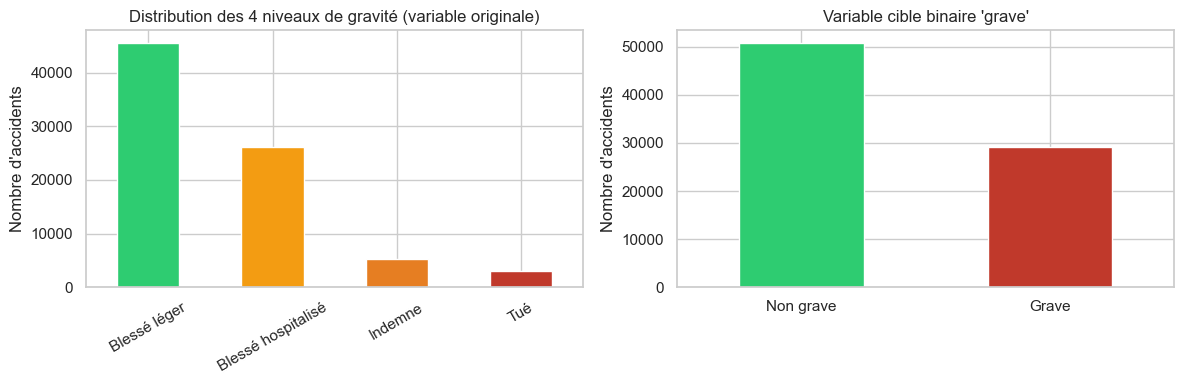

In [27]:
# Travailler sur une copie pour préserver le dataset brut
data = df.copy()

# Création de la variable cible
data = data[data["grav"].isin([1, 2, 3, 4])].copy()  # on retire la ligne avec grav=-1
data["grave"] = (data["grav"].isin([2, 3])).astype(int)

# Vérification
print("Distribution de la variable cible :")
print(data["grave"].value_counts())
print(f"\nProportion de cas graves : {data['grave'].mean()*100:.2f}%")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
data["grav"].map(MAPPINGS["grav"]).value_counts().plot(
    kind="bar", ax=ax[0], color=["#2ecc71", "#f39c12", "#e67e22", "#c0392b"]
)
ax[0].set_title("Distribution des 4 niveaux de gravité (variable originale)")
ax[0].set_xlabel(""); ax[0].set_ylabel("Nombre d'accidents")
ax[0].tick_params(axis="x", rotation=30)

data["grave"].map({0: "Non grave", 1: "Grave"}).value_counts().plot(
    kind="bar", ax=ax[1], color=["#2ecc71", "#c0392b"]
)
ax[1].set_title("Variable cible binaire 'grave'")
ax[1].set_xlabel(""); ax[1].set_ylabel("Nombre d'accidents")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

**Observations sur la cible :**
- ~36 % des accidents enregistrés sont graves (tué ou blessé hospitalisé).
- Le déséquilibre est **modéré**. Nous traiterons cela par pondération des classes (`class_weight='balanced'`) plutôt que par sur-échantillonnage (SMOTE).

### 6.2 Filtrage temporel (2018-2023) et nettoyage des variables

**Choix méthodologique : restriction à la période 2018-2023.**

La base BAAC a fait l'objet d'une refonte en 2018 (nouvelle codification, champs harmonisés et plus complets). Avant 2018, de nombreuses variables présentent des valeurs `-1` (« Non renseigné ») en grande quantité, ce qui dégrade la qualité des analyses.

Par ailleurs, la pratique cycliste a fortement évolué depuis 2018 : généralisation des vélos à assistance électrique, déploiement des aménagements cyclables post-COVID, hausse de la pratique urbaine. Modéliser sur la période récente donne donc des résultats plus représentatifs des conditions actuelles.

**Conséquences du filtre :**
- Volume restant : **~16 600 accidents** (suffisant pour la modélisation)
- Quasi-disparition des codes `-1` (de plusieurs milliers à quelques dizaines)
- Disparition quasi-totale des coordonnées GPS manquantes

On applique aussi :
- **Drop** des colonnes peu exploitables (identifiants, colonnes non standard très lacunaires)
- **Recodage** des `-1` résiduels en NaN dans les variables BAAC
- **Correction** des âges aberrants (>100) en NaN
- **Conversion** de `lat`/`long` en numérique (avec NaN pour les `0` résiduels)

In [29]:
# 1) Filtre temporel : période 2018-2023
n_before = len(data)
data = data[data["an"] >= 2018].copy()
print(f"Filtre 2018+ : {n_before:,} → {len(data):,} lignes ({(n_before-len(data))/n_before*100:.1f}% supprimées)")

# 2) Drop des colonnes inutiles ou peu exploitables
cols_to_drop = [
    "Num_Acc",          # identifiant
    "date",             # redondant avec an/mois/jour
    "com",              # code commune INSEE — trop de modalités, on garde dep à la place
    "lartpc", "larrout",  # largeurs voirie : ~20% de NaN, peu pertinent ici
    "vehiculeid", "typevehicules", "manoeuvehicules", "numVehicules",  # colonnes auxiliaires lacunaires
    "equipement",       # texte libre, beaucoup de NaN — on garde secuexist (codé) à la place
    "obs", "obsm",      # obstacles : très spécifiques, peu interprétables
]
data = data.drop(columns=[c for c in cols_to_drop if c in data.columns])

# 3) Recodage des -1 résiduels en NaN sur les variables BAAC catégorielles
cols_minus1 = ["lum", "atm", "col", "circ", "surf", "infra", "situ",
               "sexe", "trajet", "prof", "plan", "choc", "manv"]
for c in cols_minus1:
    if c in data.columns:
        data[c] = data[c].replace(-1, np.nan)

# 4) Correction des âges aberrants
data.loc[data["age"] > 100, "age"] = np.nan

# 5) Conversion lat/long en numérique (les '0' deviennent 0.0, qu'on remplace par NaN)
for c in ["lat", "long"]:
    data[c] = pd.to_numeric(data[c], errors="coerce")
    data.loc[data[c] == 0, c] = np.nan

# 6) Conversion nbv (nombre de voies) en numérique
data["nbv"] = pd.to_numeric(data["nbv"], errors="coerce")

print(f"\nShape après nettoyage : {data.shape}")
print(f"Période : {data['an'].min()} → {data['an'].max()}")
print(f"Proportion d'accidents graves : {data['grave'].mean()*100:.2f}%")
print(f"\nColonnes restantes : {list(data.columns)}")

Filtre 2018+ : 16,634 → 16,634 lignes (0.0% supprimées)

Shape après nettoyage : (16634, 28)
Période : 2018 → 2023
Proportion d'accidents graves : 38.34%

Colonnes restantes : ['an', 'mois', 'jour', 'hrmn', 'dep', 'lat', 'long', 'agg', 'int', 'col', 'lum', 'atm', 'catr', 'circ', 'nbv', 'prof', 'plan', 'surf', 'infra', 'situ', 'grav', 'sexe', 'age', 'trajet', 'secuexist', 'choc', 'manv', 'grave']
